# Banknote dimensions

Which banknotes exhibit the greatest size differences between denominations? Which are the largest overall?

Banknote dimensions differ widely across countries.

The size of a banknote impacts its practicality. Uniform dimensions enhance durability by ensuring a snug wallet fit, while also enabling vending machines and ATMs to process them seamlessly. Conversely, varied sizes assist the visually impaired in distinguishing denominations, though smaller notes can pose challenges for machine sorting and counting.

Striking a balance between these considerations is essential in currency design.

The file `banknote-dimensions.csv` shows the `length` and `width` in millimeters for 42 currencies. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

In [89]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'banknote-dimensions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('banknote-dimensions.csv')
df

,currency,code,value,length,width
0,Argentine Peso,ARS,2,155.0,65.0
1,Argentine Peso,ARS,5,155.0,65.0
2,Argentine Peso,ARS,10,155.0,65.0
3,Argentine Peso,ARS,20,155.0,65.0
4,Argentine Peso,ARS,50,155.0,65.0
...,...,...,...,...,...
245,West African Franc,XOF,500,114.0,60.0
246,West African Franc,XOF,1000,125.0,66.0
247,West African Franc,XOF,2000,130.0,65.0
248,West African Franc,XOF,5000,140.0,74.0


In [91]:
# longest and shortest banknotes for each currency
# modify the code below if you are more interested in width
length = df.groupby('currency').agg(max=('length', 'max'), min=('length', 'min')).reset_index()
length['diff'] = length['max'] - length['min']
length.head()

,currency,max,min,diff
0,Argentine Peso,155.0,155.0,0.0
1,Australian Dollar,158.0,130.0,28.0
2,Bangladeshi Taka,155.0,100.0,55.0
3,Bolivian Boliviano,140.0,140.0,0.0
4,Canadian Dollar,152.4,152.4,0.0


In [92]:
# helper function, change gap, vertical alignment, horizontal alignment, placement of gap...
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas

- Generate paired scatter plots to compare the `length` of the longest and shortest banknotes for each currency.

- Create similar paired scatter plots, but for `width` instead of `length`.

- Incorporate the Pro Tips into your visualizations.

- Add labels to data points to highlight key insights or narrate a compelling story.

- Calculate the percentage of currencies where:
	- Only the `length` remains consistent across all denominations.
	- Only the `width` remains consistent across all denominations.
	- Both `length` and `width` vary with denominations.
	- All denominations share identical `length` and `width` dimensions.

- Visualize these findings in a clear, engaging format.

Below is a preliminary paired scatter plot of banknote length to serve as a starting point.

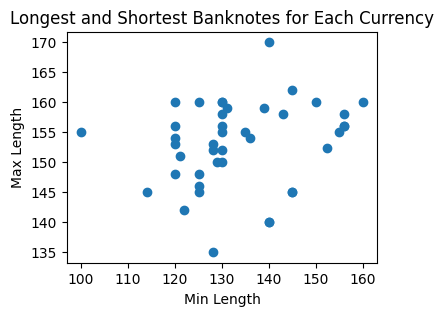

In [93]:
plt.figure(figsize=(4, 3))  
plt.scatter(length['min'], length['max'])
plt.xlabel('Min Length')
plt.ylabel('Max Length')
plt.title('Longest and Shortest Banknotes for Each Currency')
plt.show()

----------------------------------------------- Create similar paired scatter plots, but for `width` instead of `length`.----------------------------------------------------------------


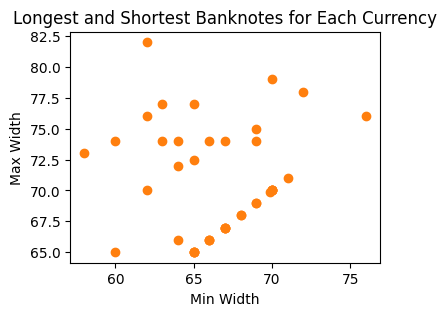

In [94]:
# YOUR CODE HERE (add additional cells as needed)
print("----------------------------------------------- Create similar paired scatter plots, but for `width` instead of `length`.----------------------------------------------------------------")
width = df.groupby('currency').agg(max=('width', 'max'), min=('width', 'min')).reset_index()
width['diff'] = length['max'] - length['min']
plt.figure(figsize=(4, 3))  
plt.scatter(width['min'],width['max'],color='C1')
plt.xlabel('Min Width')
plt.ylabel('Max Width')
plt.title('Longest and Shortest Banknotes for Each Currency')
plt.show()


------------------------------------------------ Incorporate the Pro Tips into your visualizations. ------------------------------------------------------
Use transparency (alpha) if points overlap, Add labels to highlight interesting points or outliers, Remove spines and tick marks for a cleaner look, Add soft gridlines to help compare values, Keep point size consistent unless encoding another variable, Use color to group categories or emphasize patterns


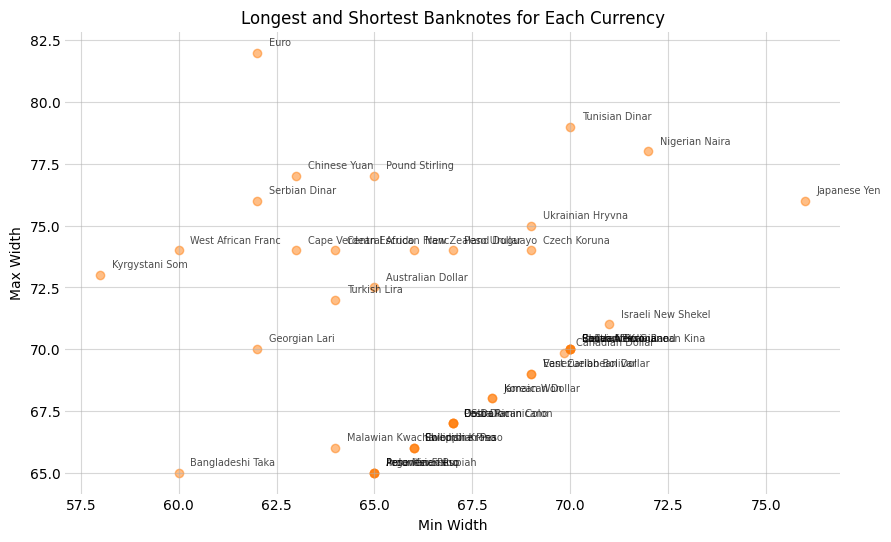

In [95]:
print("------------------------------------------------ Incorporate the Pro Tips into your visualizations. ------------------------------------------------------")
print("Use transparency (alpha) if points overlap, Add labels to highlight interesting points or outliers, Remove spines and tick marks for a cleaner look, Add soft gridlines to help compare values, Keep point size consistent unless encoding another variable, Use color to group categories or emphasize patterns")
def clean_graph():
    axos = plt.gca()
    axos.spines[['left','right','bottom','top']].set_visible(False)
    axos.tick_params('both',length=0)
    plt.grid(axis='both',alpha=0.5)

plt.figure(figsize=(10, 6))  
plt.scatter(width['min'],width['max'],color='C1', alpha=0.5)
plt.xlabel('Min Width')
plt.ylabel('Max Width')
plt.title('Longest and Shortest Banknotes for Each Currency')
clean_graph()
for i in range(len(width)):
    plt.text(width['min'][i]+ 0.3, width['max'][i]+ 0.3, width['currency'][i], fontsize=7, alpha=0.7)

plt.show()


In [109]:
print("--------------------------------------------Calculate the percentage of currencies where:  Only the `length` remains consistent across all denominations and  Only the `width` remains consistent across all denominations. and Both `length` and `width` vary with denominations. --------------------------------------------------------------------")
	
	
length_mask = ((length["max"] == length["min"])).to_numpy()
width_mask = ((width["max"] == width["min"])).to_numpy()

# print(f"Length Mask :\n{length_mask}\nWidth Mask:\n{width_mask}")


total = len(length_mask)

length_consistent = sum(length_mask & ~width_mask)/total *100
width_consistent = sum(width_mask & ~length_mask)/total *100
both_vary = sum(~length_mask & ~width_mask)/total *100
both_same = sum(length_mask & width_mask)/total *100



--------------------------------------------Calculate the percentage of currencies where:  Only the `length` remains consistent across all denominations and  Only the `width` remains consistent across all denominations. and Both `length` and `width` vary with denominations. --------------------------------------------------------------------


In [110]:
print("----------------------------------------------------------------- -  # - All denominations share identical `length` and `width` dimensions.-----------------------------------------------------------------------------")

print(f"Only length consistent: {length_consistent:.2f}%")
print(f"Only width consistent: {width_consistent:.2f}%")
print(f"Both identical: {both_same:.1f}%")
print(f"Both vary: {both_vary:.1f}%")

----------------------------------------------------------------- -  # - All denominations share identical `length` and `width` dimensions.-----------------------------------------------------------------------------
Only length consistent: 0.00%
Only width consistent: 33.33%
Both identical: 21.4%
Both vary: 45.2%
